In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import sys

# ==========================================
# 1. Configuration & Data Loading
# ==========================================
#TB 1
#FILE_PATH = '../sim_data/tb1.txt' 
#VCO_COLUMN_NAME = 'ck0' 
#LOCK_TIME_THRESHOLD = 10e-3
#STOP_TIME_THRESHOLD = 34e-3

#TB 2
FILE_PATH = '../sim_data/tb2_7.txt' 
VCO_COLUMN_NAME = 'ck0' 
LOCK_TIME_THRESHOLD = 71e-6
STOP_TIME_THRESHOLD = 150e-6

#TB 3
#FILE_PATH = '../sim_data/tb3.txt' 
#VCO_COLUMN_NAME = 'ck0' 
#LOCK_TIME_THRESHOLD = 10e-3
#STOP_TIME_THRESHOLD = 34e-3

#TB 4   
#FILE_PATH = '../sim_data/tb4.txt' 
#VCO_COLUMN_NAME = 'ck0' 
#LOCK_TIME_THRESHOLD = 30e-6
#STOP_TIME_THRESHOLD = 36e-6

#TB 5
#FILE_PATH = '../sim_data/tb5.txt' 
#VCO_COLUMN_NAME = 'ck0' 
#LOCK_TIME_THRESHOLD = 10e-3
#STOP_TIME_THRESHOLD = 34e-3

#Model + PFD
#FILE_PATH = '../sim_data/tb_PLL_PFD_model2.txt' 
#VCO_COLUMN_NAME = 'vco_out' 
#LOCK_TIME_THRESHOLD = 3e-6
#STOP_TIME_THRESHOLD = 100e-6

#FILE_PATH = '../sim_data/tb_PLL_model.txt' 
#VCO_COLUMN_NAME = 'vco_out' 


print("Loading data... (This may take a moment for large files)")
try:
    df = pd.read_csv(FILE_PATH, sep=r'\s+')
except FileNotFoundError:
    print(f"ERROR: Could not find file at {FILE_PATH}")
    sys.exit()

# Ensure the dataframe columns are lowercase for easier matching
df.columns = df.columns.str.lower()

# Slice the data to ONLY include the stable locked region
# NOTE: Ensure your simulation ran long enough! (> 0.1s for 20 kHz, ~100us for 300 MHz)

df = df[(df['time'] > LOCK_TIME_THRESHOLD) & (df['time'] < STOP_TIME_THRESHOLD)]

if df.empty:
    print(f"ERROR: The dataframe is empty. No data exists after {LOCK_TIME_THRESHOLD} seconds.")
    sys.exit()

t = df['time'].values
try:
    v_ck0 = df[VCO_COLUMN_NAME].values
except KeyError:
    print(f"ERROR: Column '{VCO_COLUMN_NAME}' not found.")
    sys.exit()

# Auto-detect Quadrature Outputs
has_quadrature = all(col in df.columns for col in ['ck90', 'ck180', 'ck270'])
if has_quadrature:
    print("-> Detected Quadrature Outputs (CK0, CK90, CK180, CK270).")
    v_ck90  = df['ck90'].values
    v_ck180 = df['ck180'].values
    v_ck270 = df['ck270'].values
else:
    print("-> Single-ended output detected. Skipping quadrature phase check.")

# ==========================================
# 2. Edge Detection Helpers
# ==========================================
v_mid = 1.65 

def get_rising_edges(v_sig, t_sig, threshold):
    crossings = np.where((v_sig[:-1] < threshold) & (v_sig[1:] >= threshold))[0]
    edges = []
    for idx in crossings:
        t1, t2 = t_sig[idx], t_sig[idx+1]
        v1, v2 = v_sig[idx], v_sig[idx+1]
        edges.append(t1 + (t2 - t1) * (threshold - v1) / (v2 - v1))
    return np.array(edges)

def calc_phase_diff(edges_lead, edges_lag, period_array):
    delta_t = []
    for t_lead in edges_lead:
        future_edges = edges_lag[edges_lag > t_lead]
        if len(future_edges) > 0:
            delta_t.append(future_edges[0] - t_lead)
    
    delta_t = np.array(delta_t)
    min_len = min(len(delta_t), len(period_array))
    delta_t = delta_t[:min_len]
    p_array = period_array[:min_len]
    return np.mean((delta_t / p_array) * 360.0)

# ==========================================
# 3. Jitter & Quadrature Calculation
# ==========================================
print("\nCalculating Jitter...")
edges_0 = get_rising_edges(v_ck0, t, v_mid)

if len(edges_0) < 2:
    print("ERROR: Less than two clock edges were detected. Simulation time is too short.")
    sys.exit()

periods = np.diff(edges_0)
if len(periods) == 0:
    print("ERROR: Period array is empty. Cannot calculate jitter.")
    sys.exit()

mean_period = np.mean(periods)
rms_jitter = np.std(periods)
pk_pk_jitter = np.max(periods) - np.min(periods)

# Dynamic Frequency Scaling Logic
fc = 1.0 / mean_period
if fc < 1e6:
    freq_scale = 1e3
    freq_label = "kHz"
    target_offset = 1e3   # Benchmark at 1 kHz for low frequency
    plot_xlim_left = 10   # Start plot at 10 Hz
else:
    freq_scale = 1e6
    freq_label = "MHz"
    target_offset = 1e6   # Benchmark at 1 MHz for high frequency
    plot_xlim_left = 10e3 # Start plot at 10 kHz

# Dynamic Time Unit Scaling for Jitter Plot
if rms_jitter > 1e-9:
    time_scale = 1e9
    time_label = "ns"
else:
    time_scale = 1e12
    time_label = "ps"

print(f"--- Jitter Results ---")
print(f"Mean Frequency: {fc / freq_scale:.2f} {freq_label}")
print(f"RMS Jitter:     {rms_jitter * 1e12:.2f} ps")
print(f"Pk-Pk Jitter:   {pk_pk_jitter * 1e12:.2f} ps")

if has_quadrature:
    print("\nCalculating Quadrature Phase Match...")
    edges_90  = get_rising_edges(v_ck90, t, v_mid)
    edges_180 = get_rising_edges(v_ck180, t, v_mid)
    edges_270 = get_rising_edges(v_ck270, t, v_mid)

    phase_0_90   = calc_phase_diff(edges_0, edges_90, periods)
    phase_90_180 = calc_phase_diff(edges_90, edges_180, periods)
    phase_180_270= calc_phase_diff(edges_180, edges_270, periods)
    phase_270_0  = calc_phase_diff(edges_270, edges_0, periods)

    err_0_90   = abs(phase_0_90 - 90.0)
    err_90_180 = abs(phase_90_180 - 90.0)
    err_180_270= abs(phase_180_270 - 90.0)
    err_270_0  = abs(phase_270_0 - 90.0)
    max_error = max(err_0_90, err_90_180, err_180_270, err_270_0)

    print(f"--- 4-Phase Quadrature Results ---")
    print(f"0°   -> 90°:   {phase_0_90:.3f}° (Error: {err_0_90:.3f}°)")
    print(f"90°  -> 180°:  {phase_90_180:.3f}° (Error: {err_90_180:.3f}°)")
    print(f"180° -> 270°:  {phase_180_270:.3f}° (Error: {err_180_270:.3f}°)")
    print(f"270° -> 0°:    {phase_270_0:.3f}° (Error: {err_270_0:.3f}°)")
    print(f"MAX PHASE ERROR: {max_error:.3f}°")

# ==========================================
# 4. Phase Noise & FFT Calculation
# ==========================================
print("\nCalculating Frequency Data...")

# --- A. Power Spectrum (Voltage FFT) ---
dt_uniform = t[1] - t[0]
N = len(v_ck0)
fft_complex = np.fft.fft(v_ck0)
fft_freqs = np.fft.fftfreq(N, d=dt_uniform)

fft_mag_dB = 20 * np.log10(np.abs(fft_complex) / np.max(np.abs(fft_complex)) + 1e-20)
pos_fft_idx = fft_freqs > 0
fft_freqs_pos = fft_freqs[pos_fft_idx]
fft_mag_pos_dB = fft_mag_dB[pos_fft_idx]

# --- B. True Phase Noise Calculation (From Time Interval Error) ---
print("Extracting Phase Error from Jitter...")
ideal_edges = edges_0[0] + np.arange(len(edges_0)) * mean_period
tie_array = edges_0 - ideal_edges  # Raw Time Interval Error

# --- THE FIX: Center the TIE to align the eye diagram perfectly on the y-axis (x=0) ---
tie_mean = np.mean(tie_array)
tie_array = tie_array - tie_mean
ideal_edges = ideal_edges + tie_mean  # Shift ideal clock to match the center of mass
# -------------------------------------------------------------------------------------

f_sample = 1.0 / mean_period 
# Force full array for maximum low-frequency resolution
nperseg_phase = len(tie_array)

offset_freqs, psd_phase = signal.welch(tie_array * 2 * np.pi * fc, fs=f_sample, window='hann', nperseg=nperseg_phase)
phase_noise_dBc = 10 * np.log10((psd_phase / 2) + 1e-20)

valid_indices = offset_freqs > 0
offset_freqs = offset_freqs[valid_indices]
phase_noise_dBc = phase_noise_dBc[valid_indices]

closest_idx = np.argmin(np.abs(offset_freqs - target_offset))
benchmark_label = "1 MHz" if target_offset == 1e6 else f"{target_offset/1e3:.0f} kHz"

print(f"--- Phase Noise Results ---")
print(f"Carrier Freq:       {fc / freq_scale:.2f} {freq_label}")
print(f"Phase Noise @ {benchmark_label}: {phase_noise_dBc[closest_idx]:.2f} dBc/Hz\n")


Loading data... (This may take a moment for large files)
-> Detected Quadrature Outputs (CK0, CK90, CK180, CK270).

Calculating Jitter...
--- Jitter Results ---
Mean Frequency: 35.00 MHz
RMS Jitter:     5.46 ps
Pk-Pk Jitter:   37.91 ps

Calculating Quadrature Phase Match...
--- 4-Phase Quadrature Results ---
0°   -> 90°:   90.000° (Error: 0.000°)
90°  -> 180°:  90.000° (Error: 0.000°)
180° -> 270°:  90.000° (Error: 0.000°)
270° -> 0°:    90.000° (Error: 0.000°)
MAX PHASE ERROR: 0.000°

Calculating Frequency Data...
Extracting Phase Error from Jitter...
--- Phase Noise Results ---
Carrier Freq:       35.00 MHz
Phase Noise @ 1 MHz: -98.73 dBc/Hz



Processing edges for Oscilloscope Eye Diagram overlay...


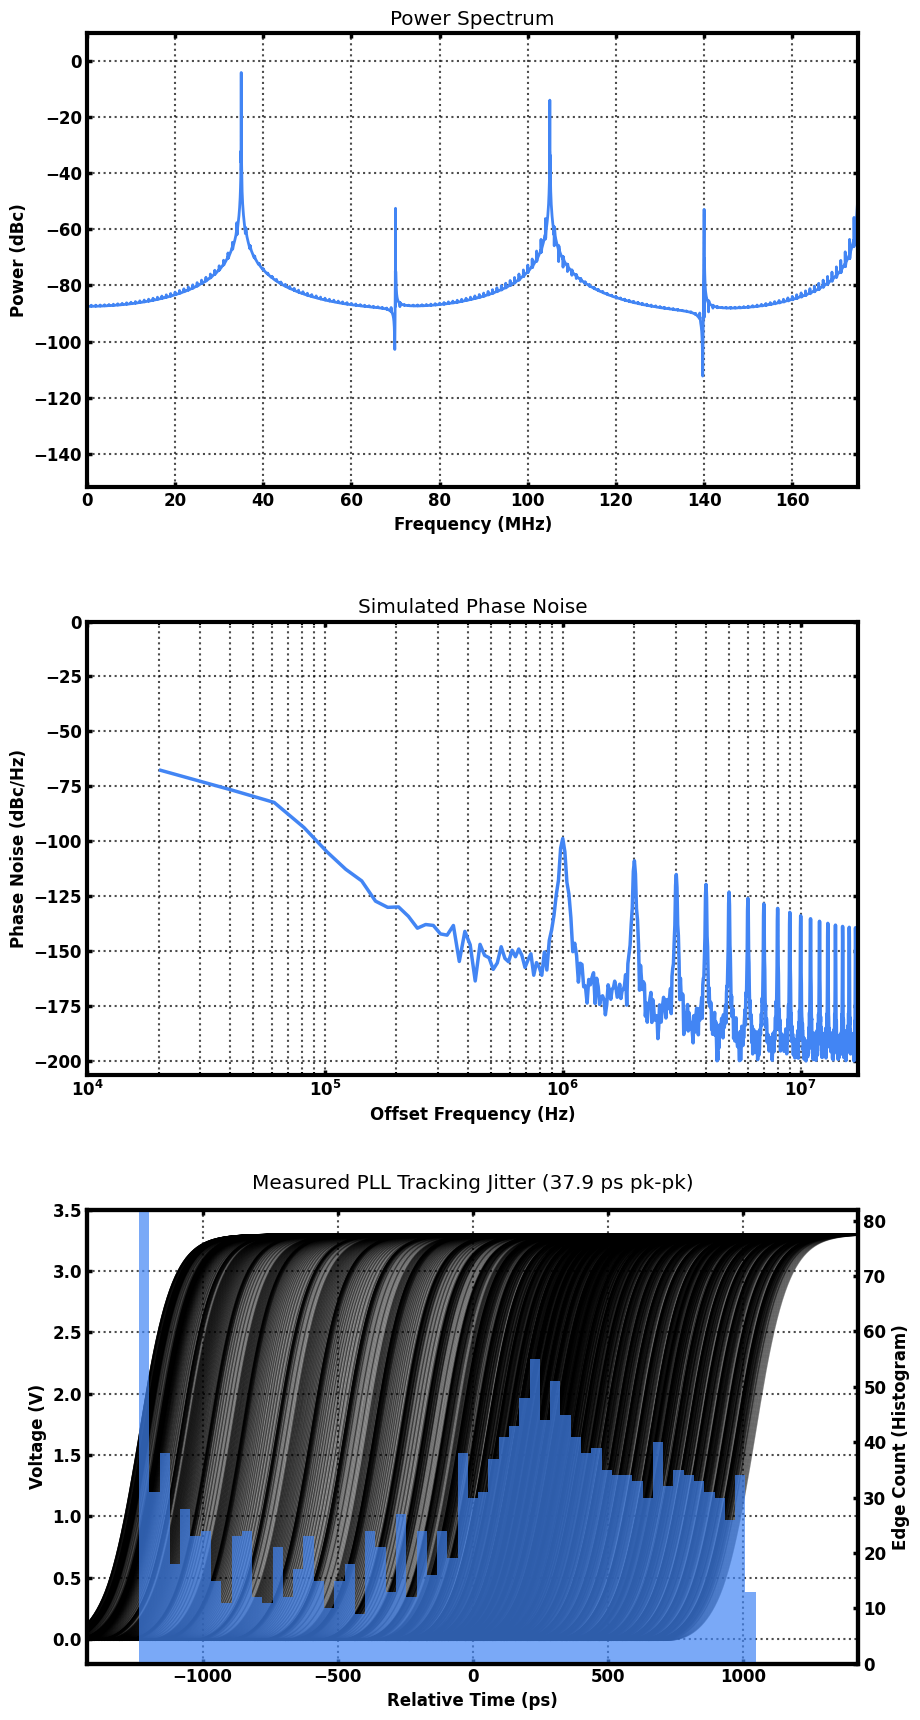

In [2]:
# ==========================================
# 5. Plotting
# ==========================================
plt.rcParams.update({
    'axes.linewidth': 3,
    'axes.labelweight': 'bold',
    'font.weight': 'bold',
    'xtick.major.width': 2.5,
    'ytick.major.width': 2.5,
    'xtick.minor.width': 1.5,
    'ytick.minor.width': 1.5,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'font.size': 12
})

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 18))

# --- Plot 1: Power Spectrum ---
ax1.plot(fft_freqs_pos / freq_scale, fft_mag_pos_dB, color='#4285F4', linewidth=2)
ax1.set_title('Power Spectrum')
ax1.set_xlabel(f'Frequency ({freq_label})')
ax1.set_ylabel('Power (dBc)')
ax1.grid(True, which='both', linestyle=':', linewidth=1.5, color='black', alpha=0.7)

min_power = np.min(fft_mag_pos_dB)
ax1.set_ylim(bottom=np.floor(min_power / 10)*8, top=10)
ax1.set_xlim(left=0, right=(fc / freq_scale) * 5)
ax1.margins(x=0) 

# --- Plot 2: Simulated Phase Noise ---
ax2.semilogx(offset_freqs, phase_noise_dBc, color='#4285F4', linewidth=2.5)
ax2.set_title('Simulated Phase Noise')
ax2.set_xlabel('Offset Frequency (Hz)')
ax2.set_ylabel('Phase Noise (dBc/Hz)')
ax2.grid(True, which='both', linestyle=':', linewidth=1.5, color='black', alpha=0.7)

ax2.set_xlim(left=plot_xlim_left, right=offset_freqs[-1])
ax2.set_ylim(top=0)

# --- Plot 3: Oscilloscope Persistence Overlay & Histogram ---
ax3.set_title(f'Measured PLL Tracking Jitter ({pk_pk_jitter * time_scale:.1f} {time_label} pk-pk)', pad=15)
ax3.set_xlabel(f'Relative Time ({time_label})')
ax3.set_ylabel('Voltage (V)')
ax3.grid(True, linestyle=':', linewidth=1.5, color='black', alpha=0.7)

print("Processing edges for Oscilloscope Eye Diagram overlay...")

zoom_window = max(pk_pk_jitter * 5, mean_period * 0.05)
num_traces = min(len(edges_0), 2000)

# Trigger on the IDEAL clock edge to expose the actual Time Interval Error
for i in range(1, num_traces - 1): 
    t_ideal = ideal_edges[i]
    
    # Slice the continuous time and voltage arrays around the IDEAL edge
    mask = (t > t_ideal - zoom_window) & (t < t_ideal + zoom_window)
    t_slice = t[mask]
    v_slice = v_ck0[mask]
    
    # Normalize the time slice so the IDEAL crossing is exactly at 0
    t_relative = (t_slice - t_ideal) * time_scale
    
    # Plot the smeared actual edges
    ax3.plot(t_relative, v_slice, color='black', alpha=0.5, linewidth=1)

ax3.set_xlim([-zoom_window * time_scale, zoom_window * time_scale])
ax3.set_ylim([-0.2, 3.5]) 

# Add the Jitter Histogram at the bottom via twinx
ax4 = ax3.twinx()
# Center the histogram bins exactly on the TIE deviations
ax4.hist(tie_array * time_scale, bins=60, color='#4285F4', alpha=0.7, density=False)
ax4.set_ylabel('Edge Count (Histogram)')

max_count = np.max(np.histogram(tie_array * time_scale, bins=60)[0])
ax4.set_ylim([0, max_count]) 

plt.tight_layout(pad=3.0)
plt.show()